In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import plotly.express as px 
df=pd .read_csv(r"C:\Users\SCA_11\Desktop\harish\Advertising (3).csv")

In [2]:
df.shape

(200, 5)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [4]:
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [6]:
df.tail()

,Unnamed: 0,TV,radio,newspaper,sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [7]:
df.describe()

,Unnamed: 0,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [8]:
df.isna().sum()

Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64

In [9]:
df.isnull().sum()

Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import numpy as np


In [5]:
#define feature (x) and target(y)

import numpy as np
import seaborn as sns
import pandas as pd
x=df[['TV','radio','newspaper']]
y=df['sales']

In [8]:
#split the data inot training and testing sets(80% train 20% test)
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)
print(f"Training set shape (x_train, y_train): {x_train.shape}, {y_train.shape}")
print(f"Testing set shape (x_test, y_test): {x_test.shape}, {y_test.shape}")

Training set shape (x_train, y_train): (160, 3), (160,)
Testing set shape (x_test, y_test): (40, 3), (40,)


In [9]:
model = LinearRegression()
model.fit(x_train, y_train)
print("model training complete")
print(f"Model Coefficients: {model.coef_}")
print(f"Model Intercept: {model.intercept_}")

model training complete
Model Coefficients: [0.04472952 0.18919505 0.00276111]
Model Intercept: 2.979067338122629


In [10]:
y_train_pred= model.predict(x_train)

r2_train = r2_score(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)

print("\n--Training set evaluation")
print(f"R-squared (train) :{r2_train:.4f}")
print(f"MAE (train) :{mae_train:.4f}")
print(f"MSE (train) :{mse_train:.4f}")
print(f"RMSE (train) :{rmse_train:.4f}")

y_test_pred = model.predict(x_test)

r2_test = r2_score(y_test, y_test_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test= mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)

print("\n--Testing set evaluation---")
print(f"R-squared (test) :{r2_test:.4f}")
print(f"MAE (test) :{mae_test:.4f}")
print(f"MSE (test) :{mse_test:.4f}")
print(f"RMSE (test) :{rmse_test:.4f}")

print("\n--Overfitting check---")
if abs(r2_train - r2_test) <0.05: 
    print("the model does not appear to be significantly overfit as R-squared values")
else:
    print("There might be some overfitting or underfitting, as there is some notable difference")


--Training set evaluation
R-squared (train) :0.8957
MAE (train) :1.1985
MSE (train) :2.7051
RMSE (train) :1.6447

--Testing set evaluation---
R-squared (test) :0.8994
MAE (test) :1.4608
MSE (test) :3.1741
RMSE (test) :1.7816

--Overfitting check---
the model does not appear to be significantly overfit as R-squared values


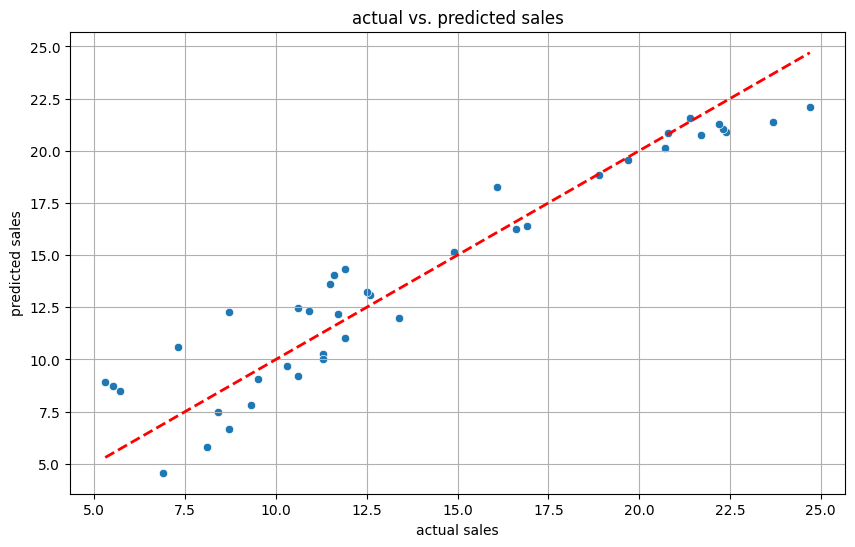

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

#create a scatter plot of actual vs. predicted values
plt.figure(figsize=(10,6))
sns.scatterplot(x = y_test, y=y_test_pred)

#plot a perfect prediction line (y=x)
plt.plot([y_test.min(), y_test.max()],[ y_test.min(), y_test.max()],'--r', linewidth = 2)

plt.title("actual vs. predicted sales")
plt.xlabel('actual sales')
plt.ylabel('predicted sales')
plt.grid(True)
plt.show()